In [ ]:
# Misc
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Pytorch
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

# Keras (for a utility function)
import keras

# SVD
from numpy.linalg import svd

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True)
tqdm.pandas()

In [ ]:
# Clipping function to keep data within valid bounds
def clip(current, low_bound, up_bound):
    low_bound = torch.FloatTensor(low_bound)
    up_bound = torch.FloatTensor(up_bound)
    clipped = torch.max(torch.min(current, up_bound), low_bound)
    return clipped


def deepfool(x_old, net, maxiters, alpha, bounds, overshoot=0.002):
    """
    Generates an adversarial examples x' from an original sample x using the DeepFool method.
    """
    x = Variable(x_old.clone(), requires_grad=True)

    output = net.forward(x)
    orig_pred = output.max(0, keepdim=True)[1]

    I = [0, 1] if orig_pred.item() == 0 else [1, 0]

    r_tot = np.zeros(x_old.numpy().shape)
    k_i = orig_pred

    loop_i = 0
    while torch.eq(k_i, orig_pred) and loop_i < maxiters:
        # Origin class gradient
        output[I[0]].backward(retain_graph=True)
        grad_orig = x.grad.data.numpy().copy()
        net.zero_grad()

        # Target class gradient
        output[I[1]].backward(retain_graph=True)
        cur_grad = x.grad.data.numpy().copy()
        net.zero_grad()

        w = cur_grad - grad_orig
        f = (output[I[1]] - output[I[0]]).data.numpy()

        pert = abs(f) / (np.linalg.norm(w.flatten())**2)
        r_i = pert * w
        r_i *= alpha # Control step size

        r_tot += r_i
        pert_x = x_old + (1 + overshoot) * torch.from_numpy(r_tot).float()
        pert_x = clip(pert_x, bounds[0], bounds[1])

        x = Variable(pert_x, requires_grad=True)
        output = net.forward(x)
        k_i = torch.tensor(np.argmax(output.data.cpu().numpy().flatten()))

        loop_i += 1

    pert_x = clip(pert_x, bounds[0], bounds[1])
    return orig_pred, k_i, pert_x.cpu(), loop_i

In [ ]:
def get_df(dataset_name):
    dataset = fetch_openml(dataset_name)
    target_col = 'target'
    df = pd.DataFrame(data=np.c_[dataset['data'], dataset[target_col]], columns=dataset['feature_names'] + [target_col])
    df[target_col] = df[target_col].apply(lambda x: 0.0 if x == 'bad' else 1.0)

    feature_names = ['checking_status', 'duration', 'credit_amount', 'savings_status', 'employment',
                     'installment_commitment', 'residence_since', 'age', 'existing_credits',
                     'num_dependents', 'own_telephone', 'foreign_worker']
    df = df[feature_names + [target_col]]

    mappings = {
        'checking_status': {'<0': 0, '0<=X<200': 1, '>=200': 2, 'no checking': 3},
        'savings_status': {'no known savings': 0, '<100': 1, '100<=X<500': 2, '500<=X<1000': 3, '>=1000': 4},
        'employment': {'unemployed': 0, '<1': 1, '1<=X<4': 2, '4<=X<7': 3, '>=7': 4},
        'own_telephone': {'none': 0, 'yes': 1},
        'foreign_worker': {'no': 0, 'yes': 1}
    }
    for col, mapping in mappings.items():
        df[col] = df[col].map(mapping)
    df = df.astype(float)
    return df, target_col, feature_names

def normalize(df, feature_names):
    scaler = MinMaxScaler()
    X = df[feature_names].values
    low_bounds = X.min(axis=0)
    up_bounds = X.max(axis=0)

    df[feature_names] = scaler.fit_transform(X)

    scaled_bounds = [scaler.transform([low_bounds])[0], scaler.transform([up_bounds])[0]]
    return scaler, df, scaled_bounds

def get_weights(df, target_col):
    cor = df.corr()
    cor_target = abs(cor[target_col])
    weights = cor_target.drop(target_col).values
    weights = weights / np.linalg.norm(weights)
    return weights

In [ ]:
class GermanNet(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(GermanNet, self).__init__()
        self.linear1 = torch.nn.Linear(D_in, H)
        self.linear2 = torch.nn.Linear(H, H)
        self.linear3 = torch.nn.Linear(H, D_out)
        self.relu = torch.nn.ReLU()
        self.softmax = torch.nn.Softmax(dim=0)

    def forward(self, x):
        h1 = self.relu(self.linear1(x))
        h2 = self.relu(self.linear2(h1))
        a3 = self.linear3(h2)
        y = self.softmax(a3)
        return y

def train(model, X_train, y_train, epochs=200, batch_size=100, lr=1e-4):
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_classes = y_train.shape[1]

    model.train()
    print("Training model...")
    for epoch in range(epochs):
        for i in range(0, X_train.size(0), batch_size):
            inputs = Variable(X_train[i:i+batch_size], requires_grad=True)
            labels = y_train[i:i+batch_size]

            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
    model.eval()
    print("Training complete.")
    return model

In [ ]:
SEED = 42
DATASET = 'credit-g'

# Load and Prepare Data
df_orig, target, feature_names = get_df(DATASET)

# Balance dataset
len_0, len_1 = (df_orig[target] == 0).sum(), (df_orig[target] == 1).sum()
df_0 = df_orig[df_orig[target] == 0].sample(min(len_0, len_1), random_state=SEED)
df_1 = df_orig[df_orig[target] == 1].sample(min(len_0, len_1), random_state=SEED)
df = pd.concat((df_0, df_1)).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Normalize data and get feature weights
scaler, df, bounds = normalize(df, feature_names)
weights = get_weights(df, target)

# Train/Test split
df_train, df_test = train_test_split(df, test_size=0.3, random_state=SEED)

print("Data loading and preparation complete.")
print(f"Training data shape: {df_train.shape}")
print(f"Test data shape: {df_test.shape}")
df_test.head()

Data loading and preparation complete.
Training data shape: (420, 13)
Test data shape: (180, 13)


,checking_status,duration,credit_amount,savings_status,employment,installment_commitment,residence_since,age,existing_credits,num_dependents,own_telephone,foreign_worker,target
110,0.0,0.294118,0.091175,0.25,0.50,0.333333,1.000000,0.035714,0.000000,1.0,0.0,1.0,0.0
419,0.0,0.058824,0.169192,0.25,0.75,0.000000,1.000000,0.357143,0.333333,0.0,0.0,0.0,1.0
565,1.0,0.382353,0.395168,0.00,0.00,1.000000,0.000000,0.607143,0.000000,0.0,1.0,1.0,0.0
77,0.0,0.073529,0.059936,0.25,0.25,0.666667,0.333333,0.142857,0.000000,0.0,1.0,1.0,0.0
181,0.0,0.294118,0.061042,0.25,0.75,1.000000,1.000000,0.071429,0.333333,0.0,0.0,1.0,0.0


In [ ]:
X_train_tensor = torch.FloatTensor(df_train[feature_names].values)
y_train_tensor = torch.FloatTensor(keras.utils.to_categorical(df_train[target], num_classes=2))

model = GermanNet(D_in=len(feature_names), H=100, D_out=2)
model = train(model, X_train_tensor, y_train_tensor)

Training model...
Training complete.


In [ ]:
# Use the entire test set for the attack
df_attack_samples = df_test

# This optional print statement helps confirm you are using all the data
print(f"Using the full test set of {len(df_attack_samples)} samples for analysis.")

print("\n--- Performing SVD on ORIGINAL Data ---")
original_matrix = df_attack_samples[feature_names].to_numpy()
print(f"\nProcessing original data matrix with shape: {original_matrix.shape}")

U_orig, s_orig, Vh_orig = svd(original_matrix, full_matrices=False)

print("SVD complete for original data.")
print(f"   Shape of U (left singular vectors):  {U_orig.shape}")
print(f"   Shape of s (singular values):        {s_orig.shape}")
print(f"   Shape of Vh (right singular vectors): {Vh_orig.shape}")

Using the full test set of 180 samples for analysis.

--- Performing SVD on ORIGINAL Data ---

Processing original data matrix with shape: (180, 12)
SVD complete for original data.
   Shape of U (left singular vectors):  (180, 12)
   Shape of s (singular values):        (12,)
   Shape of Vh (right singular vectors): (12, 12)


In [ ]:
# ========================================================================== #
#    PARAMETERS TO CHANGE: Adjust these values to control attack intensity   #
# ========================================================================== #
config = {
    'MaxIters'     : 1000,    # Max iterations for the attack algorithms.
    'Alpha'        : 0.1,     # Step size / scaling factor for perturbations. Larger is more intense.
    'Lambda'       : 0.5,     # Trade-off for LowProFool. Smaller prioritizes fooling over stealth.
    'Model'        : model,
    'Weights'      : weights,
    'Bounds'       : bounds,
    'FeatureNames' : feature_names
}

# Generate adversarial examples for both methods
results_df = []

for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc="Generating Adversarials"):
    x_tensor = torch.FloatTensor(row[feature_names].values)


    # DeepFool - Call with explicit arguments from the config
    _, _, x_adv_df, _ = deepfool(x_old=x_tensor,
                                 net=config['Model'],
                                 maxiters=config['MaxIters'],
                                 alpha=config['Alpha'],
                                 bounds=config['Bounds'])
    results_df.append(x_adv_df.numpy().flatten())


df_adv_df = pd.DataFrame(results_df, columns=feature_names)

print("\nAdversarial example generation complete.")
print(f"Shape of DeepFool adversarial data:  {df_adv_df.shape}")

Generating Adversarials: 100%|██████████| 180/180 [02:00<00:00,  1.50it/s]


Adversarial example generation complete.
Shape of DeepFool adversarial data:  (180, 12)


In [ ]:
print("\n--- Performing SVD on ADVERSARIAL Data ---")

# Convert pandas DataFrames to NumPy matrices
adv_matrix_df = df_adv_df.to_numpy()

# Perform SVD on the DeepFool adversarial matrix
print(f"\n2. Processing DeepFool matrix with shape: {adv_matrix_df.shape}")
U_df, s_df, Vh_df = svd(adv_matrix_df, full_matrices=False)
print("SVD complete for DeepFool.")
print(f"   Shape of U (left singular vectors):  {U_df.shape}")
print(f"   Shape of s (singular values):        {s_df.shape}")
print(f"   Shape of Vh (right singular vectors): {Vh_df.shape}")


--- Performing SVD on ADVERSARIAL Data ---

2. Processing DeepFool matrix with shape: (180, 12)
SVD complete for DeepFool.
   Shape of U (left singular vectors):  (180, 12)
   Shape of s (singular values):        (12,)
   Shape of Vh (right singular vectors): (12, 12)


# Systematic Perturbation Analysis

Now, we will perform a systematic analysis to understand how the data's structure changes as we increase the intensity of the adversarial attack.

Our process will be:
1.  Define a range of attack intensities (`Alpha` values).
2.  Loop through each intensity level. In each loop:
    - Generate a new set of adversarial examples.
    - Perform SVD and store the resulting singular values.
3.  Visualize the results in two ways:
    - **A line plot** to compare the singular value spectrums directly.
    - **A t-SNE plot** to visualize how the data points shift in a 2D space.

Starting systematic analysis for DeepFool...
--- Processing for Alpha = 0.01 ---


Alpha 0.01: 100%|██████████| 180/180 [03:39<00:00,  1.22s/it]


--- Processing for Alpha = 0.1 ---


Alpha 0.1: 100%|██████████| 180/180 [02:00<00:00,  1.50it/s]


--- Processing for Alpha = 1.0 ---


...

--- Processing for Alpha = 5.0 ---


Alpha 5.0: 100%|██████████| 180/180 [00:00<00:00, 483.75it/s]


--- Processing for Alpha = 10.0 ---


Alpha 10.0: 100%|██████████| 180/180 [00:00<00:00, 485.80it/s]



Analysis complete. All adversarial data for DeepFool generated and SVD performed.


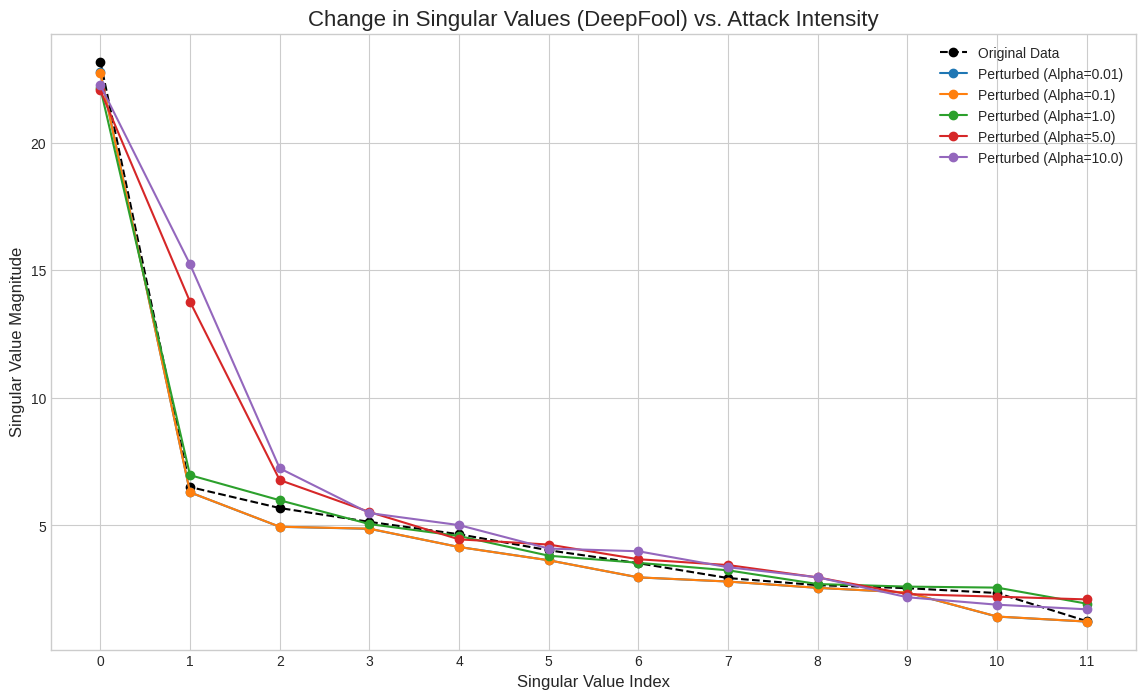

In [ ]:
# FOR DEEPFOOL RUN THIS

# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Experimental Parameters ---
# Define the different levels of attack intensity (Alpha) to test.
alpha_levels_to_test = [0.01, 0.1, 1.0, 5.0, 10.0]

# --- 2. Get Baseline SVD for Original Data ---
# This assumes 's_orig' from Cell 8 is still in memory.
# If not, you may need to re-run Cell 8.

# --- 3. Loop, Generate Data, and Store SVD Results ---
singular_values_results_df = {}
adversarial_dataframes_df = {} # To store data for t-SNE

print("Starting systematic analysis for DeepFool...")
for alpha_val in alpha_levels_to_test:
    print(f"--- Processing for Alpha = {alpha_val} ---")

    # Generate adversarial examples for the current alpha
    current_results = []
    for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc=f"Alpha {alpha_val}"):
        x_tensor = torch.FloatTensor(row[feature_names].values)

        # Using DeepFool for this analysis
        _, _, x_adv, _ = deepfool(x_old=x_tensor,
                                  net=config['Model'],
                                  maxiters=config['MaxIters'],
                                  alpha=alpha_val, # Use the current alpha from the loop
                                  bounds=config['Bounds'])
        current_results.append(x_adv.numpy().flatten())

    # Create a dataframe for the generated data
    df_adv_current = pd.DataFrame(current_results, columns=feature_names, index=df_attack_samples.index)
    adversarial_dataframes_df[alpha_val] = df_adv_current

    # Perform SVD and store the singular values
    adv_matrix_current = df_adv_current.to_numpy()
    _, s_current, _ = svd(adv_matrix_current, full_matrices=False)
    singular_values_results_df[alpha_val] = s_current

print("\nAnalysis complete. All adversarial data for DeepFool generated and SVD performed.")


# --- 4. Visualize the Singular Values ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))

# Plot the original singular values as a baseline
plt.plot(s_orig, marker='o', linestyle='--', color='black', label='Original Data')

# Plot the singular values for each alpha level
for alpha_val, s_perturbed in singular_values_results_df.items():
    plt.plot(s_perturbed, marker='o', linestyle='-', label=f'Perturbed (Alpha={alpha_val})')

plt.title('Change in Singular Values (DeepFool) vs. Attack Intensity', fontsize=16)
plt.xlabel('Singular Value Index', fontsize=12)
plt.ylabel('Singular Value Magnitude', fontsize=12)
plt.xticks(range(len(s_orig)))
plt.legend()
plt.grid(True)
plt.show()


Running t-SNE for DeepFool results... (this may take a moment)
t-SNE complete.


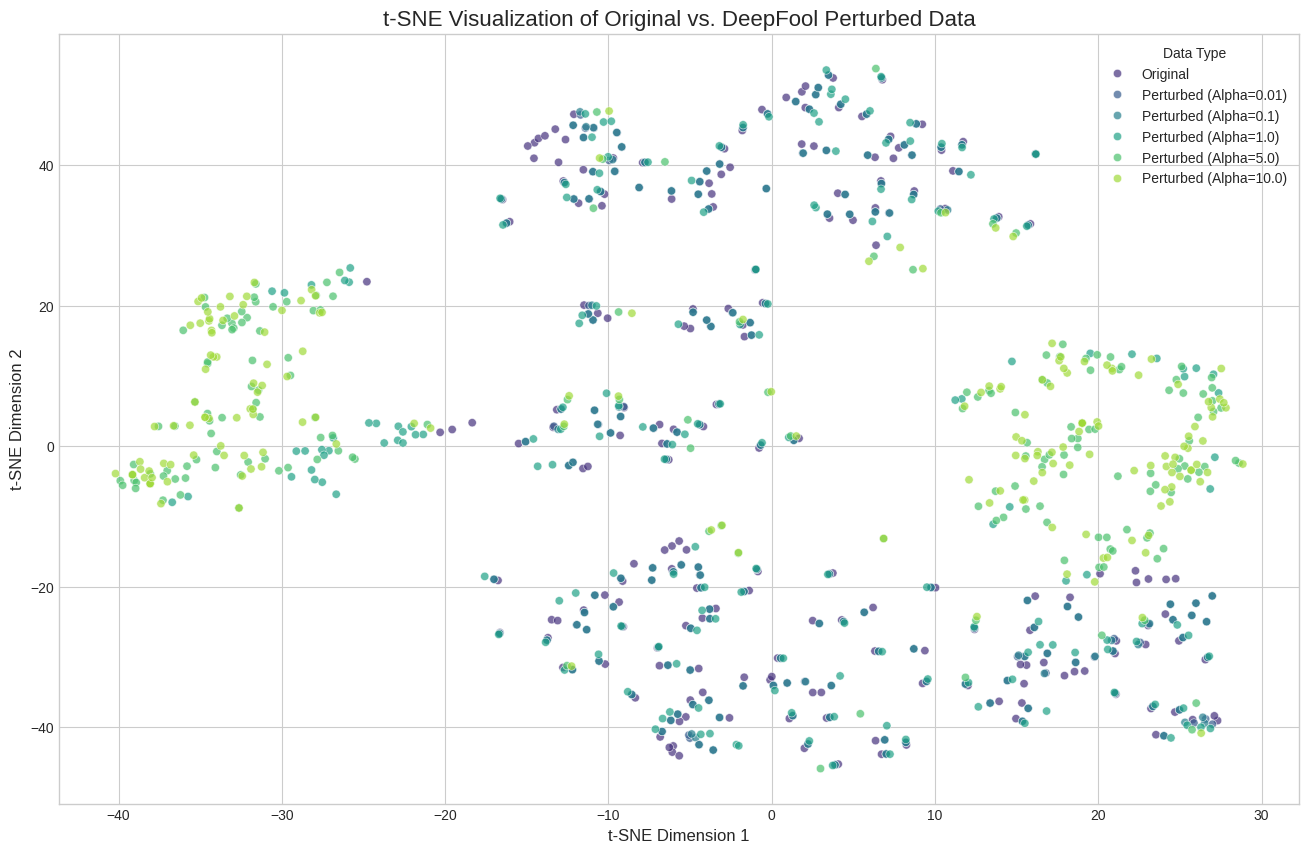

In [ ]:
# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Visualize Data Manifold with t-SNE for DeepFool ---

# Prepare the data for t-SNE by combining all dataframes
all_dfs_for_tsne_df = []

# Add the original data first
# This assumes 'df_attack_samples' is still in memory from Cell 8
df_original_for_tsne = df_attack_samples[feature_names].copy()
df_original_for_tsne['data_type'] = 'Original'
all_dfs_for_tsne_df.append(df_original_for_tsne)

# Add the adversarial dataframes from the DeepFool analysis
# This assumes 'adversarial_dataframes_df' exists from your DeepFool analysis cell
for alpha_val, df_adv in adversarial_dataframes_df.items():
    df_adv_copy = df_adv.copy()
    df_adv_copy['data_type'] = f'Perturbed (Alpha={alpha_val})'
    all_dfs_for_tsne_df.append(df_adv_copy)

# Concatenate into one big dataframe
combined_df_df = pd.concat(all_dfs_for_tsne_df, ignore_index=True)

# Separate features and labels
features_df = combined_df_df.drop('data_type', axis=1)
labels_df = combined_df_df['data_type']

print("\nRunning t-SNE for DeepFool results... (this may take a moment)")
tsne_df = TSNE(n_components=2, verbose=0, perplexity=30, n_iter=1000, random_state=SEED)
tsne_results_df = tsne_df.fit_transform(features_df)
print("t-SNE complete.")

# Add t-SNE results back to the dataframe
combined_df_df['tsne-2d-one'] = tsne_results_df[:,0]
combined_df_df['tsne-2d-two'] = tsne_results_df[:,1]

# Plot the results
plt.figure(figsize=(16, 10))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="data_type",
    palette=sns.color_palette("viridis", len(alpha_levels_to_test) + 1), # Using a different palette
    data=combined_df_df,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE Visualization of Original vs. DeepFool Perturbed Data', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Data Type')
plt.grid(True)
plt.show()

Starting DeepFool analysis for Alpha...
--- Processing for Alpha = 0.01 ---


Alpha 0.01: 100%|██████████| 180/180 [03:35<00:00,  1.20s/it]


Success Rate for Alpha=0.01: 40.56%
--- Processing for Alpha = 0.1 ---


Alpha 0.1: 100%|██████████| 180/180 [02:00<00:00,  1.50it/s]


Success Rate for Alpha=0.1: 51.67%
--- Processing for Alpha = 0.5 ---


...

Success Rate for Alpha=1.0: 100.00%
--- Processing for Alpha = 5.0 ---


Alpha 5.0: 100%|██████████| 180/180 [00:00<00:00, 502.22it/s]


Success Rate for Alpha=5.0: 100.00%
--- Processing for Alpha = 10.0 ---


Alpha 10.0: 100%|██████████| 180/180 [00:00<00:00, 514.93it/s]


Success Rate for Alpha=10.0: 100.00%


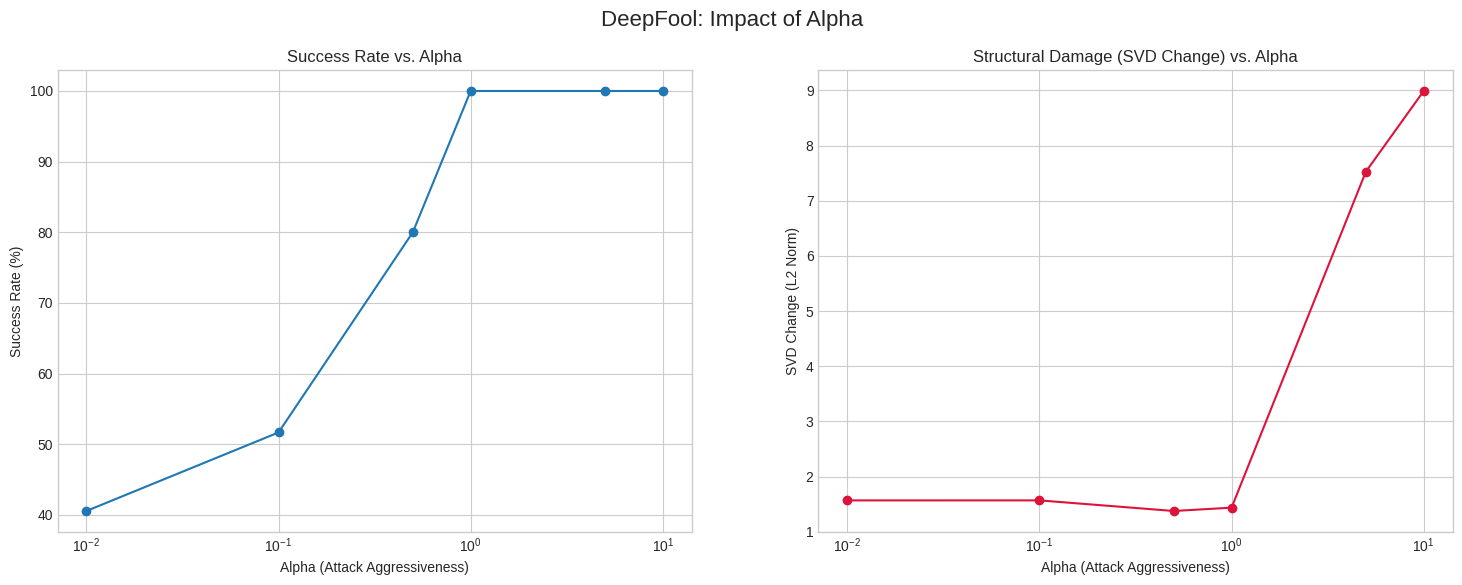

In [ ]:
# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from numpy.linalg import svd
import numpy as np

# ===================================================================
# Main Experiment Setup
# ===================================================================

# --- 1. Define Experimental Parameters ---
alpha_values_to_test = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

# This list will store a dictionary for each experimental run
df_alpha_results = []

print("Starting DeepFool analysis for Alpha...")
for alpha_val in alpha_values_to_test:
    print(f"--- Processing for Alpha = {alpha_val} ---")

    successful_attacks_counter = 0
    adversarial_examples = []

    for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc=f"Alpha {alpha_val}"):
        x_tensor = torch.FloatTensor(row[feature_names].values)

        # Using the DeepFool function
        orig_pred, adv_pred, x_adv, _ = deepfool(
            x_old=x_tensor, net=config['Model'], maxiters=1000,
            alpha=alpha_val, bounds=config['Bounds']
        )
        adversarial_examples.append(x_adv.numpy().flatten())

        # *** EFFICIENT SUCCESS CHECK (INSIDE THE LOOP) ***
        if orig_pred.item() != adv_pred.item():
            successful_attacks_counter += 1

    # --- Calculate Metrics for this alpha value ---
    success_rate = successful_attacks_counter / len(df_attack_samples)
    print(f"Success Rate for Alpha={alpha_val}: {success_rate:.2%}")

    adv_matrix_current = np.array(adversarial_examples)
    _, s_perturbed, _ = svd(adv_matrix_current, full_matrices=False)
    svd_change = np.linalg.norm(s_orig - s_perturbed)

    df_alpha_results.append({
        'alpha': alpha_val,
        'success_rate': success_rate,
        'svd_change': svd_change
    })

# --- 4. Prepare Data and Visualize ---
results_df_df_alpha = pd.DataFrame(df_alpha_results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('DeepFool: Impact of Alpha', fontsize=16)

# Plot 1: Success Rate vs. Alpha
ax1.plot(results_df_df_alpha['alpha'], results_df_df_alpha['success_rate'] * 100, marker='o', linestyle='-')
ax1.set_title('Success Rate vs. Alpha')
ax1.set_xlabel('Alpha (Attack Aggressiveness)')
ax1.set_ylabel('Success Rate (%)')
ax1.set_xscale('log')
ax1.grid(True)

# Plot 2: SVD Change vs. Alpha
ax2.plot(results_df_df_alpha['alpha'], results_df_df_alpha['svd_change'], marker='o', linestyle='-', color='crimson')
ax2.set_title('Structural Damage (SVD Change) vs. Alpha')
ax2.set_xlabel('Alpha (Attack Aggressiveness)')
ax2.set_ylabel('SVD Change (L2 Norm)')
ax2.set_xscale('log')
ax2.grid(True)

plt.show()

Starting DeepFool analysis for Alpha...
--- Processing for Alpha = 0.01 ---


Alpha 0.01: 100%|██████████| 180/180 [03:37<00:00,  1.21s/it]


--- Processing for Alpha = 0.1 ---


Alpha 0.1: 100%|██████████| 180/180 [01:54<00:00,  1.58it/s]


--- Processing for Alpha = 0.5 ---


...

Alpha 5.0: 100%|██████████| 180/180 [00:00<00:00, 373.94it/s]


--- Processing for Alpha = 10.0 ---


Alpha 10.0: 100%|██████████| 180/180 [00:00<00:00, 390.54it/s]


Full analysis complete.

--- Summary of Experimental Results ---


,alpha,success_rate,svd_change
0,0.01,0.488889,1.569119
1,0.10,0.505556,1.569575
2,0.50,0.888889,1.377497
3,1.00,0.966667,1.437737
4,5.00,0.966667,7.526441
5,10.00,0.972222,8.988023


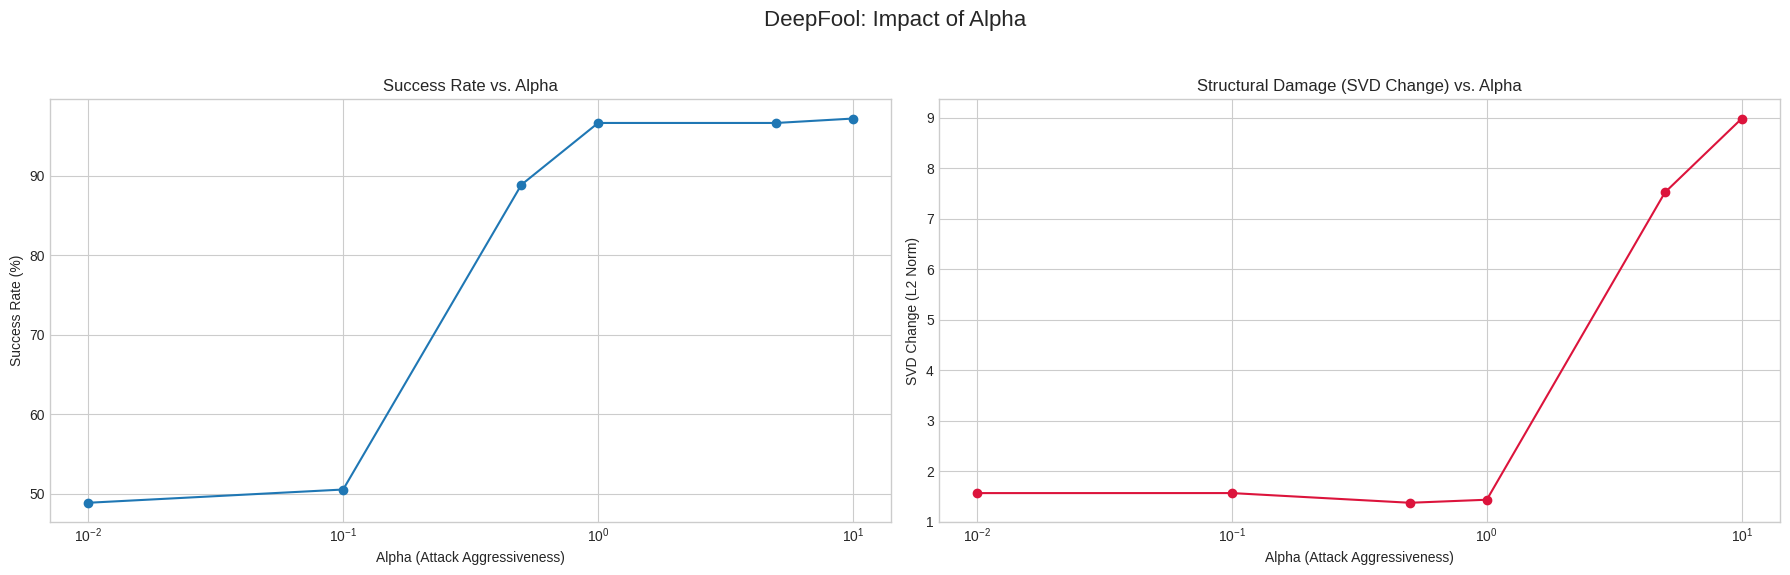

In [ ]:
# ===================================================================
# Self-contained imports to make this cell runnable independently
# ===================================================================
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from numpy.linalg import svd
import numpy as np

# ===================================================================
# Helper function to calculate success rate
# ===================================================================
def calculate_success_rate(original_df, adversarial_df, model, feature_names):
    # Get predictions for the original, clean data
    x_orig_tensor = torch.FloatTensor(original_df[feature_names].values)
    with torch.no_grad():
        y_orig_pred = np.argmax(model(x_orig_tensor).numpy(), axis=1)

    # Get predictions for the new, adversarial data
    x_adv_tensor = torch.FloatTensor(adversarial_df[feature_names].values)
    with torch.no_grad():
        y_adv_pred = np.argmax(model(x_adv_tensor).numpy(), axis=1)

    # The attack is successful if the prediction is different
    successful_attacks = np.sum(y_orig_pred != y_adv_pred)

    return successful_attacks / len(original_df)

# ===================================================================
# Main Experiment Setup
# ===================================================================

# --- 1. Define Experimental Parameters ---
# Define the ranges of attack intensities (Alpha) to test.
alpha_values_to_test = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

# This list will store a dictionary for each experimental run
experimental_results = []

# --- 2. Loop to Test All Combinations ---
print("Starting DeepFool analysis for Alpha...")
for alpha_val in alpha_values_to_test:
    print(f"--- Processing for Alpha = {alpha_val} ---")

    current_adversarial_examples = []
    # Generate adversarial examples for the current parameter combination
    for _, row in tqdm(df_attack_samples.iterrows(), total=df_attack_samples.shape[0], desc=f"Alpha {alpha_val}"):
        x_tensor = torch.FloatTensor(row[feature_names].values)

        # Using the deepfool function
        _, _, x_adv, _ = deepfool(
            x_old=x_tensor, net=config['Model'], maxiters=1000,
            alpha=alpha_val, bounds=config['Bounds']
        )
        current_adversarial_examples.append(x_adv.numpy().flatten())

    # --- 3. Calculate Metrics for this combination ---
    df_adv_current = pd.DataFrame(current_adversarial_examples, columns=feature_names, index=df_attack_samples.index)

    # Calculate overall success rate
    success_rate = calculate_success_rate(df_attack_samples, df_adv_current, model, feature_names)

    # Perform SVD and calculate the structural change
    adv_matrix_current = df_adv_current.to_numpy()
    _, s_perturbed, _ = svd(adv_matrix_current, full_matrices=False)
    # We measure the "structural damage" as the distance between the original and perturbed singular value vectors
    svd_change = np.linalg.norm(s_orig - s_perturbed)

    # Store all results
    experimental_results.append({
        'alpha': alpha_val,
        'success_rate': success_rate,
        'svd_change': svd_change
    })

print("\nFull analysis complete.")

# --- 4. Prepare Data for Visualization ---
results_df = pd.DataFrame(experimental_results)
print("\n--- Summary of Experimental Results ---")
display(results_df)

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('DeepFool: Impact of Alpha', fontsize=16)

# Plot 1: Success Rate vs. Alpha
ax1.plot(results_df['alpha'], results_df['success_rate'] * 100, marker='o', linestyle='-')
ax1.set_title('Success Rate vs. Alpha')
ax1.set_xlabel('Alpha (Attack Aggressiveness)')
ax1.set_ylabel('Success Rate (%)')
ax1.set_xscale('log')
ax1.grid(True)

# Plot 2: SVD Change vs. Alpha
ax2.plot(results_df['alpha'], results_df['svd_change'], marker='o', linestyle='-', color='crimson')
ax2.set_title('Structural Damage (SVD Change) vs. Alpha')
ax2.set_xlabel('Alpha (Attack Aggressiveness)')
ax2.set_ylabel('SVD Change (L2 Norm)')
ax2.set_xscale('log')
ax2.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()